In [8]:
import requests as req
from bs4 import BeautifulSoup as bs
import numpy as np
import pandas as pd

In [10]:
url = "https://www.daraz.pk/catalog/?q=laptop"

response = req.get(url=url)
print(response.status_code)
html = response.content

200


b'\r\n<!DOCTYPE html>\n<html lang="en">\n  <head>\n    <meta charset="utf-8" />\n    <meta name="data-spm" content="a2a0e" />\n    <meta http-equiv="x-ua-compatible" content="ie=edge" />\n    <meta name="viewport" content="width=device-width" />\n    <meta name="referrer" content="origin" />\n    <meta name="lzd-itrace-close-auto-monitor" content="assetPerf,imagesPerf">\n    \n      <meta name="aplus-rhost-v" content="sg.mmstat.com">\n      <meta name="aplus-rhost-g" content="sg.mmstat.com">\n      <meta name="aplus-cpvdata" content="{&quot;daraz_web_version&quot;:&quot;2.0.0&quot;}">\n      <meta name="aplus-exdata" content="{&quot;daraz_web_version&quot;:&quot;2.0.0&quot;}">\n    \n    <link rel="preconnect dns-prefetch" href="//cart.daraz.pk" />\n    <link rel="preconnect dns-prefetch" href="//member.daraz.pk" />\n    <link rel="preconnect dns-prefetch" href="//acs-m.daraz.pk" />\n    <link rel="preconnect dns-prefetch" href="//laz-img-cdn.alicdn.com" />\n    <link rel="preconnect d
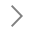

In [11]:
html


<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<meta content="a2a0e" name="data-spm"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="width=device-width" name="viewport"/>
<meta content="origin" name="referrer"/>
<meta content="assetPerf,imagesPerf" name="lzd-itrace-close-auto-monitor"/>
<meta content="sg.mmstat.com" name="aplus-rhost-v"/>
<meta content="sg.mmstat.com" name="aplus-rhost-g"/>
<meta content='{"daraz_web_version":"2.0.0"}' name="aplus-cpvdata"/>
<meta content='{"daraz_web_version":"2.0.0"}' name="aplus-exdata"/>
<link href="//cart.daraz.pk" rel="preconnect dns-prefetch"/>
<link href="//member.daraz.pk" rel="preconnect dns-prefetch"/>
<link href="//acs-m.daraz.pk" rel="preconnect dns-prefetch"/>
<link href="//laz-img-cdn.alicdn.com" rel="preconnect dns-prefetch"/>
<link href="//g.alicdn.com" rel="preconnect dns-prefetch"/>
<link href="//g.lazcdn.com" rel="preconnect dns-prefetch"/>
<link href="//o.alicdn.com" rel="preconnect dns-pr
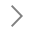

In [ ]:
html_content = bs(html, "html.parser")
html_content 

In [ ]:
html_content.prettify()

'<!DOCTYPE html>\n<html lang="en">\n <head>\n  <meta charset="utf-8"/>\n  <meta content="a2a0e" name="data-spm"/>\n  <meta content="ie=edge" http-equiv="x-ua-compatible"/>\n  <meta content="width=device-width" name="viewport"/>\n  <meta content="origin" name="referrer"/>\n  <meta content="assetPerf,imagesPerf" name="lzd-itrace-close-auto-monitor"/>\n  <meta content="sg.mmstat.com" name="aplus-rhost-v"/>\n  <meta content="sg.mmstat.com" name="aplus-rhost-g"/>\n  <meta content=\'{"daraz_web_version":"2.0.0"}\' name="aplus-cpvdata"/>\n  <meta content=\'{"daraz_web_version":"2.0.0"}\' name="aplus-exdata"/>\n  <link href="//cart.daraz.pk" rel="preconnect dns-prefetch"/>\n  <link href="//member.daraz.pk" rel="preconnect dns-prefetch"/>\n  <link href="//acs-m.daraz.pk" rel="preconnect dns-prefetch"/>\n  <link href="//laz-img-cdn.alicdn.com" rel="preconnect dns-prefetch"/>\n  <link href="//g.alicdn.com" rel="preconnect dns-prefetch"/>\n  <link href="//g.lazcdn.com" rel="preconnect dns-prefetch

In [40]:
html_content.title

<title>Buy laptop Online at Best Price in Pakistan - Daraz.pk</title>

In [33]:
import requests
from bs4 import BeautifulSoup

url = "https://www.daraz.pk/catalog/?q=laptop"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

products = soup.find_all("div", class_="Bm3ON")

print("Products found:", len(products))  # DEBUG

for product in products[:5]:
    title = product.find("img")["alt"]
    price = product.find("span", class_="ooOxS")

    print("Title:", title)
    print("Price:", price.text if price else "N/A")
    print("-" * 40)


Products found: 0


In [34]:
print(response.status_code)
print(response.text[:1000])

200

<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="utf-8" />
    <meta name="data-spm" content="a2a0e" />
    <meta http-equiv="x-ua-compatible" content="ie=edge" />
    <meta name="viewport" content="width=device-width" />
    <meta name="referrer" content="origin" />
    <meta name="lzd-itrace-close-auto-monitor" content="assetPerf,imagesPerf">
    
      <meta name="aplus-rhost-v" content="sg.mmstat.com">
      <meta name="aplus-rhost-g" content="sg.mmstat.com">
      <meta name="aplus-cpvdata" content="{&quot;daraz_web_version&quot;:&quot;2.0.0&quot;}">
      <meta name="aplus-exdata" content="{&quot;daraz_web_version&quot;:&quot;2.0.0&quot;}">
    
    <link rel="preconnect dns-prefetch" href="//cart.daraz.pk" />
    <link rel="preconnect dns-prefetch" href="//member.daraz.pk" />
    <link rel="preconnect dns-prefetch" href="//acs-m.daraz.pk" />
    <link rel="preconnect dns-prefetch" href="//laz-img-cdn.alicdn.com" />
    <link rel="preconnect dns-prefetch" href="/

In [42]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
import time
import csv

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.get("https://www.daraz.pk/catalog/?q=laptop")

time.sleep(5)  # let JS load

products = driver.find_elements(By.CLASS_NAME, "Bm3ON")
print("Products found:", len(products))

with open("daraz_laptops.csv", mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Title", "Price"])  # header

    for product in products:
        try:
            title = product.find_element(By.TAG_NAME, "img").get_attribute("alt")
            price = product.find_element(By.CLASS_NAME, "ooOxS").text

            writer.writerow([title, price])

            print("Saved:", title)
        except Exception as e:
            print("Skipped one product:", e)

driver.quit()


Products found: 40
Saved: LENOVO CHROMEBOOK 100E - 4GB RAM DDR4 - 32GB SSD EMMC - 11.6" SCREEN - PLAYSTORE SUPPORTED - AUE UPDATE 2027
Saved: Acer 5th Generation Laptop 4GB Ram 128GB SSD Windows 10
Saved: USA STOCK TOUCH SCREEN 360° Folding Lenovo 300e Chromebook 4GB Ram 32 GB Storage Update 2029/2027 FREE TOUCH STYLUS PEN
Saved: Apple MacBook Pro A1278 - 8GB RAM 256GB SSD  - 2.5GHz Dual-Core Intel Core i5 - Mid 2012 13.3-inch LED Display - Dual Operating System MacOS Catalina 10.15 - Silver - Daraz Like New Laptops
Saved: Dell Chromebook 3180/3100 11.6 Inch HD , 4GB RAM, Windows 10, WiFi, New - 6 Months Warranty
Saved: Lenovo | AMD A4-9120C 9th Gen | 4GB DDR4 RAM | 32GB SSD eMMC + 40GB Could Storage Free  | 1.60Ghz Processor | 11.6 Display | Windows 11 | 2029 Update AUE Chromebook
Saved: Microsoft Surface pro 5 Core  i5 7th Generation 8GB 256GB ssd 4gb Intel iris Graphics 2 in 1 tablet laptop
Saved: Hp Chromebook 11 G6 EE | 4GB RAM DDR4 | 16GB SSD EMMC | Playstore supported | 11.6" sc

In [44]:
df = pd.read_csv("daraz_laptops.csv")
df

,Title,Price
0,LENOVO CHROMEBOOK 100E - 4GB RAM DDR4 - 32GB S...,"Rs. 8,640"
1,Acer 5th Generation Laptop 4GB Ram 128GB SSD W...,"Rs. 17,777"
2,USA STOCK TOUCH SCREEN 360° Folding Lenovo 300...,"Rs. 14,428"
3,Apple MacBook Pro A1278 - 8GB RAM 256GB SSD -...,"Rs. 38,170"
4,"Dell Chromebook 3180/3100 11.6 Inch HD , 4GB R...","Rs. 9,499"
5,Lenovo | AMD A4-9120C 9th Gen | 4GB DDR4 RAM |...,"Rs. 8,999"
6,Microsoft Surface pro 5 Core i5 7th Generatio...,"Rs. 41,999"
7,Hp Chromebook 11 G6 EE | 4GB RAM DDR4 | 16GB S...,"Rs. 8,299"
8,Lenovo | ChromeBook 100E | 4GB RAM | 32GB Stor...,"Rs. 8,799"
9,Microsoft surface pro 6 i5 8th generation 8gb ...,"Rs. 48,999"
